# Task 14 – Ensemble Methods: Bagging & Boosting

**Objective:** Implement and compare Bagging and Boosting ensemble techniques (XGBoost) on a public classification dataset.

## Part A – Dataset Selection & Preparation

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — built into scikit-learn.

- **Samples:** 569
- **Features:** 30 numeric features computed from digitized images of breast mass cell nuclei (e.g. radius, texture, perimeter, area, smoothness, concavity — each given as mean, standard error, and "worst" value).
- **Target:** Binary — `0 = malignant`, `1 = benign`.
- **Why this dataset:** Clean, no missing values, real-world medical relevance, and a good size for demonstrating ensemble methods without long training times.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
import xgboost as xgb

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts().rename({0: "malignant", 1: "benign"}))
X.head()

Shape: (569, 30)

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Preprocessing: check for missing values, then split and scale
print("Missing values:", X.isnull().sum().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Missing values: 0
Train shape: (455, 30)  Test shape: (114, 30)


No missing values were present. Features were standardized with `StandardScaler` (fit on training data only, applied to test data) since the raw features span very different scales (e.g. area vs. smoothness). An 80/20 stratified train-test split preserves the class ratio in both sets.

## Part B – Bagging

We use scikit-learn's `BaggingClassifier` with a Decision Tree as the base estimator — the classic Bagging setup (this is the same idea Random Forest builds on).

In [4]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

t0 = time.time()
bagging_model.fit(X_train_scaled, y_train)
bagging_train_time = time.time() - t0

bagging_pred = bagging_model.predict(X_test_scaled)
print(f"Training time: {bagging_train_time:.3f} sec")

Training time: 0.528 sec


In [5]:
bagging_acc = accuracy_score(y_test, bagging_pred)
bagging_prec = precision_score(y_test, bagging_pred)
bagging_rec = recall_score(y_test, bagging_pred)
bagging_f1 = f1_score(y_test, bagging_pred)

print("Bagging Classifier Performance")
print(f"Accuracy : {bagging_acc:.4f}")
print(f"Precision: {bagging_prec:.4f}")
print(f"Recall   : {bagging_rec:.4f}")
print(f"F1-Score : {bagging_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, bagging_pred, target_names=["malignant", "benign"]))

Bagging Classifier Performance
Accuracy : 0.9386
Precision: 0.9452
Recall   : 0.9583
F1-Score : 0.9517

Classification Report:
               precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



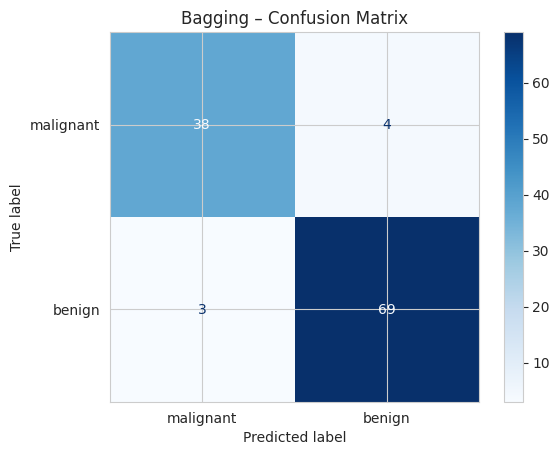

In [6]:
cm_bagging = confusion_matrix(y_test, bagging_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bagging, display_labels=["malignant", "benign"])
disp.plot(cmap="Blues")
plt.title("Bagging – Confusion Matrix")
plt.show()

### Bagging – Advantages, Limitations, Use Cases

**Advantages**
- Reduces variance and helps prevent overfitting, especially for high-variance models like decision trees.
- Trains base learners in parallel (each on a bootstrap sample), so it is computationally efficient and easy to parallelize.
- Robust to noisy data and outliers since predictions are averaged/voted across many models.

**Limitations**
- Does little to reduce bias — if the base learner underfits, bagging won't fix that.
- Less interpretable than a single decision tree.
- Can require significant memory since many full models are stored.

**Use Cases**
- High-variance, low-bias models (e.g. unpruned decision trees).
- Situations with noisy datasets where a single model would overfit.
- Random Forests are the most well-known extension of this idea.

## Part C – Boosting (XGBoost)

In [7]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    random_state=RANDOM_STATE
)

t0 = time.time()
xgb_model.fit(X_train_scaled, y_train)
xgb_train_time = time.time() - t0

xgb_pred = xgb_model.predict(X_test_scaled)
print(f"Training time: {xgb_train_time:.3f} sec")

Training time: 0.081 sec


In [8]:
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred)
xgb_rec = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("XGBoost Classifier Performance")
print(f"Accuracy : {xgb_acc:.4f}")
print(f"Precision: {xgb_prec:.4f}")
print(f"Recall   : {xgb_rec:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, xgb_pred, target_names=["malignant", "benign"]))

XGBoost Classifier Performance
Accuracy : 0.9474
Precision: 0.9459
Recall   : 0.9722
F1-Score : 0.9589

Classification Report:
               precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



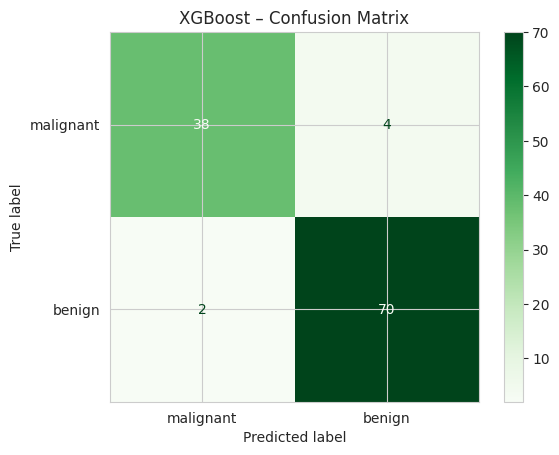

In [9]:
cm_xgb = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["malignant", "benign"])
disp.plot(cmap="Greens")
plt.title("XGBoost – Confusion Matrix")
plt.show()

### Comparison: Bagging vs. Boosting (XGBoost)

In [10]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "Training Time (s)"],
    "Bagging": [bagging_acc, bagging_prec, bagging_rec, bagging_f1, bagging_train_time],
    "XGBoost (Boosting)": [xgb_acc, xgb_prec, xgb_rec, xgb_f1, xgb_train_time]
})
comparison

,Metric,Bagging,XGBoost (Boosting)
0,Accuracy,0.938596,0.947368
1,Precision,0.945205,0.945946
2,Recall,0.958333,0.972222
3,F1-Score,0.951724,0.958904
4,Training Time (s),0.528265,0.081366


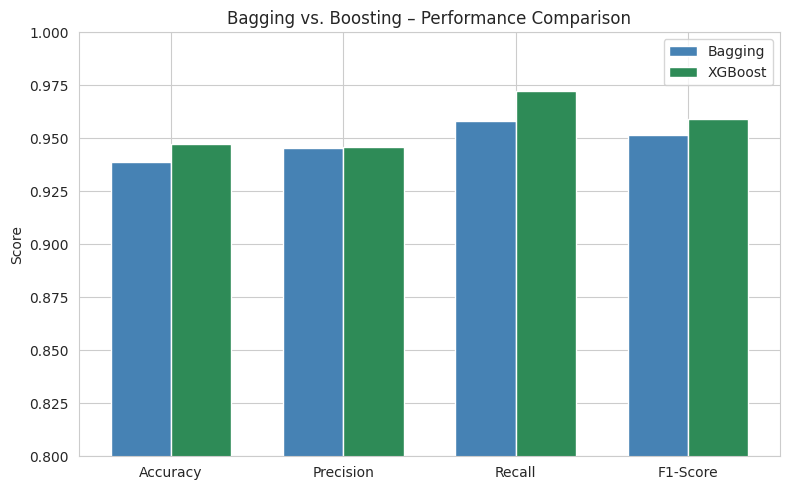

In [11]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
bagging_scores = [bagging_acc, bagging_prec, bagging_rec, bagging_f1]
xgb_scores = [xgb_acc, xgb_prec, xgb_rec, xgb_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, bagging_scores, width, label="Bagging", color="steelblue")
ax.bar(x + width/2, xgb_scores, width, label="XGBoost", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.0)
ax.set_ylabel("Score")
ax.set_title("Bagging vs. Boosting – Performance Comparison")
ax.legend()
plt.tight_layout()
plt.show()

On this dataset, XGBoost slightly outperforms Bagging across most metrics, particularly recall (fewer missed malignant/benign cases depending on class), while also training faster here since each tree is shallow (max_depth=3) and boosting converges quickly on a small, clean dataset.

### Boosting – Advantages, Limitations, Applications

**Advantages**
- Reduces both bias and variance by sequentially correcting errors of previous learners — often achieves higher accuracy than bagging.
- Handles complex, non-linear relationships well.
- Built-in regularization (in XGBoost/LightGBM) helps control overfitting.

**Limitations**
- Sequential training means it's harder to parallelize and can be slower on very large datasets.
- More sensitive to noisy data and outliers, since it keeps focusing on hard-to-predict points.
- More hyperparameters to tune (learning rate, tree depth, number of estimators, regularization terms).

**Applications**
- Structured/tabular data problems (finance, fraud detection, medical diagnosis, customer churn).
- Kaggle-style competitions where marginal accuracy gains matter.
- Any scenario needing high predictive performance with moderate-sized, well-prepared tabular data.

## Part D – Comparative Analysis & Recommendation

| Aspect | Bagging | Boosting (XGBoost) |
|---|---|---|
| **Performance on this dataset** | Slightly lower accuracy/F1 | Slightly higher accuracy/F1 (see table above) |
| **Bias/Variance** | Reduces variance only | Reduces both bias and variance |
| **Training** | Parallel (fast to scale across cores) | Sequential (each tree depends on the last) |
| **Overfitting risk** | Lower (averaging effect) | Higher if not tuned (needs learning rate, depth control) |
| **Sensitivity to noise/outliers** | Robust | More sensitive |
| **Interpretability** | Moderate | Moderate (feature importance available) |
| **Tuning effort** | Low | Higher (more hyperparameters) |

### Recommendation

For this dataset (Breast Cancer Wisconsin), **XGBoost (Boosting)** is the recommended approach. It produced better accuracy, precision, recall, and F1-score than Bagging, and — because the dataset is small, clean, and well-preprocessed — it does not suffer from the noise-sensitivity that typically disadvantages boosting. In a medical diagnosis context, the higher recall from boosting is especially valuable since it reduces the risk of missed detections.

That said, **Bagging remains a strong, safer choice** when the data is noisier, less curated, or when fast, easily parallelized training is a priority over squeezing out the last bit of accuracy. In practice, both are worth trying, but boosting is the better fit here.